In [4]:
import pandas as pd
import requests

In [5]:
url = "https://en.wikipedia.org/wiki/List_of_largest_companies_in_the_United_States_by_revenue"

headers = {
    "User-Agent": "Mozilla/5.0"
}

response = requests.get(url, headers=headers)

print(response.status_code)

200


In [9]:
tables = pd.read_html(response.text)

print("Jumlah table:", len(tables))

Jumlah table: 3


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_5260\1213960897.py:1: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(response.text)


In [7]:
df = tables[0]

df.head()

,Rank,Name,Industry,Revenue (USD millions),Revenue growth,Employees,Headquarters
0,1,Walmart,Retail,680985,5.1%,2100000,"Bentonville, Arkansas"
1,2,Amazon,Retail and cloud computing,637959,11.0%,1556000,"Seattle, Washington"
2,3,UnitedHealth Group,Healthcare,400278,7.7%,400000,"Minnetonka, Minnesota"
3,4,Apple,Technology,391035,2.0%,164000,"Cupertino, California"
4,5,CVS Health,Healthcare,372809,4.2%,259500,"Woonsocket, Rhode Island"


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Rank                    100 non-null    int64 
 1   Name                    100 non-null    object
 2   Industry                100 non-null    object
 3   Revenue (USD millions)  100 non-null    int64 
 4   Revenue growth          100 non-null    object
 5   Employees               100 non-null    int64 
 6   Headquarters            100 non-null    object
dtypes: int64(3), object(4)
memory usage: 5.6+ KB


In [10]:
df.columns

Index(['Rank', 'Name', 'Industry', 'Revenue (USD millions)', 'Revenue growth',
       'Employees', 'Headquarters'],
      dtype='object')

In [11]:
df.shape

(100, 7)

In [12]:
df.describe()

,Rank,Revenue (USD millions),Employees
count,100.000000,100.00000,1.000000e+02
mean,50.500000,130499.62000,1.619777e+05
std,29.011492,116235.76346,2.682762e+05
min,1.000000,45043.00000,4.200000e+03
25%,25.750000,56804.75000,4.475000e+04
50%,50.500000,84784.50000,8.570000e+04
75%,75.250000,148911.00000,1.886625e+05
max,100.000000,680985.00000,2.100000e+06


In [13]:
df['Revenue growth'] = (
    df['Revenue growth']
    .str.replace('%', '', regex=False)
    .astype(float)
)

In [14]:
df.head()

,Rank,Name,Industry,Revenue (USD millions),Revenue growth,Employees,Headquarters
0,1,Walmart,Retail,680985,5.1,2100000,"Bentonville, Arkansas"
1,2,Amazon,Retail and cloud computing,637959,11.0,1556000,"Seattle, Washington"
2,3,UnitedHealth Group,Healthcare,400278,7.7,400000,"Minnetonka, Minnesota"
3,4,Apple,Technology,391035,2.0,164000,"Cupertino, California"
4,5,CVS Health,Healthcare,372809,4.2,259500,"Woonsocket, Rhode Island"


In [15]:
top10 = df.nlargest(10, 'Revenue (USD millions)')

top10[['Name', 'Revenue (USD millions)']]

,Name,Revenue (USD millions)
0,Walmart,680985
1,Amazon,637959
2,UnitedHealth Group,400278
3,Apple,391035
4,CVS Health,372809
5,Berkshire Hathaway,371433
6,Alphabet,350018
7,Exxon Mobil,349595
8,McKesson Corporation,308951
9,Cencora,293959


In [17]:
df['Industry'].value_counts().head(10)

Industry
Financials                        16
Retail                             9
Petroleum                          9
Technology                         9
Healthcare                         7
Insurance                          6
Pharmaceutical                     5
Aerospace and defense              4
Technology and cloud computing     3
Telecommunications                 3
Name: count, dtype: int64

In [18]:
df.nlargest(10, 'Employees')[['Name', 'Employees']]

,Name,Employees
0,Walmart,2100000
1,Amazon,1556000
23,The Home Depot,470100
40,Target,440000
48,FedEx,422100
26,Kroger,409000
2,UnitedHealth Group,400000
5,Berkshire Hathaway,392400
46,United Parcel Service,372180
75,TJX,364000


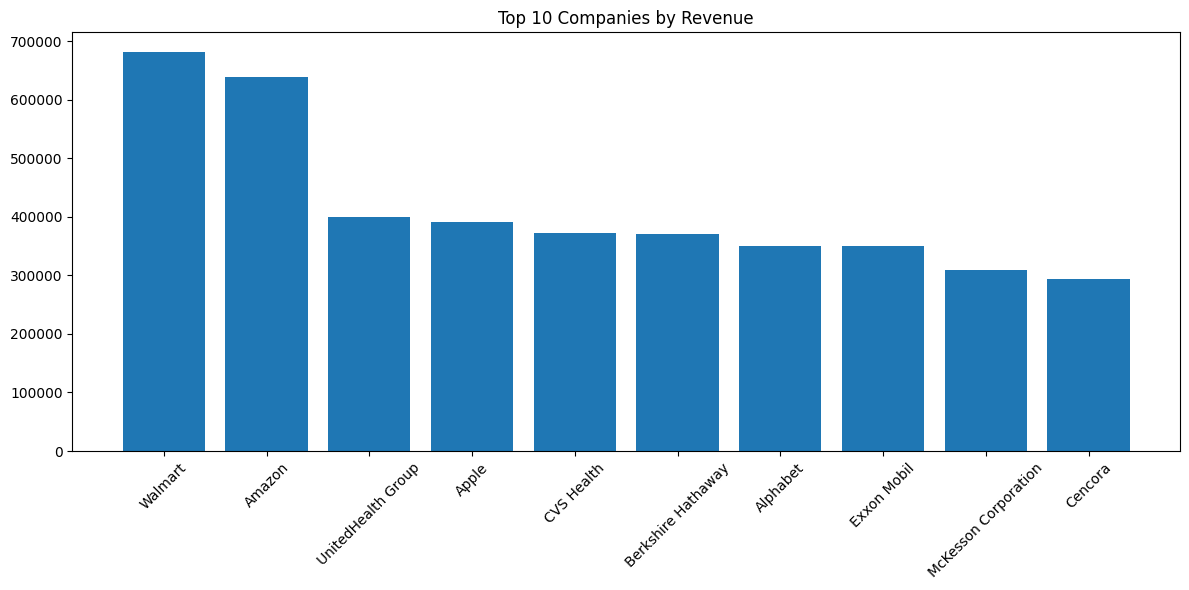

In [19]:
import matplotlib.pyplot as plt

top10 = df.nlargest(10, 'Revenue (USD millions)')

plt.figure(figsize=(12,6))

plt.bar(top10['Name'], top10['Revenue (USD millions)'])

plt.xticks(rotation=45)

plt.title('Top 10 Companies by Revenue')

plt.tight_layout()

plt.show()

In [20]:
df.to_csv(
    'largest_companies_clean.csv',
    index=False
)

print('Dataset berhasil disimpan')

Dataset berhasil disimpan


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Rank                    100 non-null    int64  
 1   Name                    100 non-null    object 
 2   Industry                100 non-null    object 
 3   Revenue (USD millions)  100 non-null    int64  
 4   Revenue growth          100 non-null    float64
 5   Employees               100 non-null    int64  
 6   Headquarters            100 non-null    object 
dtypes: float64(1), int64(3), object(3)
memory usage: 5.6+ KB


In [22]:
industry_count = df['Industry'].value_counts()

industry_count.head(10)

Industry
Financials                        16
Retail                             9
Petroleum                          9
Technology                         9
Healthcare                         7
Insurance                          6
Pharmaceutical                     5
Aerospace and defense              4
Technology and cloud computing     3
Telecommunications                 3
Name: count, dtype: int64

In [23]:
top10_revenue = df.nlargest(
    10,
    'Revenue (USD millions)'
)

top10_revenue[
    ['Name','Revenue (USD millions)']
]

,Name,Revenue (USD millions)
0,Walmart,680985
1,Amazon,637959
2,UnitedHealth Group,400278
3,Apple,391035
4,CVS Health,372809
5,Berkshire Hathaway,371433
6,Alphabet,350018
7,Exxon Mobil,349595
8,McKesson Corporation,308951
9,Cencora,293959


In [29]:
top10_employees = df.nlargest(
    10,
    'Employees'
)

top10_employees[
    ['Name','Employees']
]

,Name,Employees
0,Walmart,2100000
1,Amazon,1556000
23,The Home Depot,470100
40,Target,440000
48,FedEx,422100
26,Kroger,409000
2,UnitedHealth Group,400000
5,Berkshire Hathaway,392400
46,United Parcel Service,372180
75,TJX,364000


In [25]:
avg_revenue = (
    df.groupby('Industry')
      ['Revenue (USD millions)']
      .mean()
      .sort_values(ascending=False)
)

avg_revenue.head(10)

Industry
Retail and cloud computing             637959.000000
Conglomerate                           371433.000000
Pharmacy wholesale                     293959.000000
Healthcare                             245650.000000
Technology and cloud computing         219297.666667
Automotive                             186217.000000
Health insurance                       182441.000000
Retail                                 180898.888889
Petroleum                              134242.777778
Conglomerate and telecommunications    122336.000000
Name: Revenue (USD millions), dtype: float64

In [30]:
import matplotlib.pyplot as plt

In [31]:
df.to_csv(
    'largest_companies_clean.csv',
    index=False
)